# Multitask GPQR

In [ ]:
import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import UnwhitenedVariationalStrategy
from gpytorch.variational import LMCVariationalStrategy
from gpytorch.means import ConstantMean, Mean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.mtgpqr import MultitaskQuantileGP, MultitaskALDLikelihood

try:
    import sys
    import os

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.linspace(0.1, 0.9, 9).to(device)
true_quantiles = mean(x) + std(x) * Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

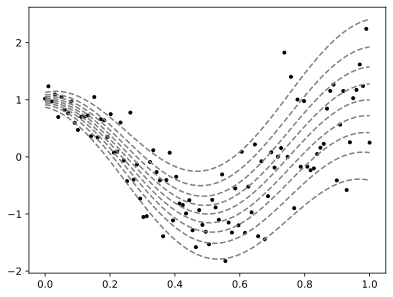

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

In [ ]:
class PriorMean(Mean):
    def __init__(self, batch_shape=torch.Size([])):
        super().__init__()
        self.batch_shape = batch_shape
        self.register_parameter("offset", torch.nn.Parameter(torch.zeros(*batch_shape)))

    def forward(self, x):
        res = mean(x).squeeze(-1)
        return res + self.offset.unsqueeze(-1)


prior_mean = PriorMean(batch_shape=torch.Size([len(q)])).to(device)

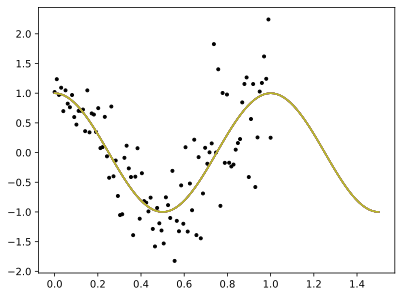

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_pred.cpu(), prior_mean(x_pred).detach().cpu().T)
plt.show()

## Define models and likelihoods

In [ ]:
num_latents = len(q) - 2

In [ ]:
class MyGP_ConstantMean(MultitaskQuantileGP):
    def __init__(self, inducing_points, num_quantiles, num_latents):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = LMCVariationalStrategy(
            UnwhitenedVariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=False,
            ),
            num_tasks=num_quantiles,
            num_latents=num_latents,
        )
        mean = ConstantMean(batch_shape=torch.Size([num_latents]))
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(variational_strategy, mean, covar)


inducing_points = x.detach().clone()
gp_constantmean = MyGP_ConstantMean(inducing_points, len(q), num_latents).to(device)
likelihood_constantmean = MultitaskALDLikelihood(q).to(device)

In [ ]:
class MyGP_PriorMean(MultitaskQuantileGP):
    def __init__(self, inducing_points, num_quantiles, num_latents):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = LMCVariationalStrategy(
            UnwhitenedVariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=False,
            ),
            num_tasks=num_quantiles,
            num_latents=num_latents,
        )
        mean = PriorMean(batch_shape=torch.Size([num_latents]))
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(variational_strategy, mean, covar)


inducing_points = x.detach().clone()
gp_priormean = MyGP_PriorMean(inducing_points, len(q), num_latents).to(device)
likelihood_priormean = MultitaskALDLikelihood(q).to(device)

## Train

In [ ]:
gp_constantmean.train()
likelihood_constantmean.train()
mll = VariationalELBO(likelihood_constantmean, gp_constantmean, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp_constantmean.parameters()) + list(likelihood_constantmean.parameters()),
    lr=0.001,
)

for _ in range(1000):
    output = gp_constantmean(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [ ]:
gp_priormean.train()
likelihood_priormean.train()
mll = VariationalELBO(likelihood_priormean, gp_priormean, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp_priormean.parameters()) + list(likelihood_priormean.parameters()),
    lr=0.001,
)

for _ in range(1000):
    output = gp_priormean(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

## Evaluate

In [ ]:
gp_constantmean.eval()
with torch.no_grad():
    quantiles_constantmean = gp_constantmean.mean_quantiles(x_pred)

In [ ]:
gp_priormean.eval()
with torch.no_grad():
    quantiles_priormean = gp_priormean.mean_quantiles(x_pred)

## Plot result

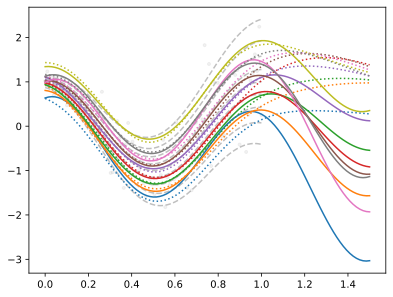

In [ ]:
colors = plt.cm.tab10(range(len(q)))

plt.scatter(x.cpu(), y.cpu(), c="gray", marker=".", alpha=0.1)
plt.plot(x.cpu(), true_quantiles.cpu(), "--", c="gray", alpha=0.5)

for i in range(len(q)):
    plt.plot(x_pred.cpu(), quantiles_constantmean[:, i].cpu(), ":", color=colors[i])
    plt.plot(x_pred.cpu(), quantiles_priormean[:, i].cpu(), color=colors[i])

plt.show()